# Evaluation: Extreme Scenarios with GNN Dispatch

This notebook evaluates the **GNN Dispatch** pipeline on extreme-criticality
scenarios. The GNN replaces both the Decoder and LP Worker stages:

| Pipeline | Steps |
|----------|-------|
| **Baseline** (with decoder) | HTE -> EBM -> Decoder -> LP Worker |
| **No decoder** | HTE -> EBM -> LP Worker (raw binaries) |
| **GNN Dispatch** | HTE -> EBM -> **DispatchGNN** |

**Key advantage**: GNN dispatch is orders of magnitude faster than LP solving
(milliseconds vs seconds per scenario).

**Prerequisites**:
- `outputs/extreme_criticality_scenarios/` with 100 scenarios + MILP reports
- `outputs/gnn_dispatch/dispatch_gnn_best.pt` (trained DispatchGNN)
- Models: `best_encoder.pt`, `ebm_v3_final.pt`
- Baseline results: `outputs/pipeline_eval_extreme/pipeline_eval_extreme.pkl`

## 1. Install Dependencies

In [1]:
import subprocess, sys

print('Installing PyTorch 2.5.1 and PyTorch Geometric...')

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
    'torch', 'torchvision', 'torchaudio', 'torch-scatter', 'torch-sparse', 'torch-geometric'],
    capture_output=True)

!pip install -q torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.1+cu124.html
!pip install -q torch-geometric
!pip install -q numpy scipy tqdm pandas matplotlib seaborn scikit-learn pyomo highspy thrml

print('Dependencies installed')

Installing PyTorch 2.5.1 and PyTorch Geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 68.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 126.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 114.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 67.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 142.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 12.

## 2. Mount Drive & Setup Paths

In [1]:
import importlib, sys

modules_to_clear = [m for m in sys.modules if m.startswith('src.')]
for m in modules_to_clear:
    del sys.modules[m]
print(f'Cleared {len(modules_to_clear)} cached modules')

Cleared 0 cached modules


In [2]:
import os, sys, json, time, pickle
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from tqdm.auto import tqdm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

REPO_PATH = Path('/content/drive/MyDrive/benchmark')
sys.path.insert(0, str(REPO_PATH))
os.chdir(REPO_PATH)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Repo: {REPO_PATH}')
print(f'Device: {DEVICE}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

Mounted at /content/drive
Repo: /content/drive/MyDrive/benchmark
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
import shutil, glob

pycache_dirs = glob.glob(str(REPO_PATH / 'src/**/__pycache__'), recursive=True)
for d in pycache_dirs:
    shutil.rmtree(d)
print(f'Purged {len(pycache_dirs)} __pycache__ directories')

# Verify GNN dispatch flag exists
runner_src = (REPO_PATH / 'src/eval/pipeline_runner.py').read_text(encoding='utf-8')
assert 'use_gnn_dispatch' in runner_src, 'BUG: use_gnn_dispatch flag missing from pipeline_runner!'
print('use_gnn_dispatch flag verified')

Purged 8 __pycache__ directories
use_gnn_dispatch flag verified


## 3. Configuration

In [4]:
EXTREME_DIR = REPO_PATH / 'outputs/extreme_criticality_scenarios'
REPORTS_DIR = EXTREME_DIR / 'reports'
OUTPUT_DIR  = REPO_PATH / 'outputs/pipeline_eval_extreme_gnn_dispatch'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GNN_MODEL_PATH = 'outputs/gnn_dispatch/dispatch_gnn_best.pt'

# Baseline results (with decoder)
BASELINE_PKL = REPO_PATH / 'outputs/pipeline_eval_extreme/pipeline_eval_extreme.pkl'
# No-decoder results
ND_PKL = REPO_PATH / 'outputs/pipeline_eval_extreme_no_decoder/pipeline_eval_extreme_no_decoder.pkl'

sc_count = len(list(EXTREME_DIR.glob('scenario_*.json')))
rp_count = len(list(REPORTS_DIR.glob('scenario_*.json'))) if REPORTS_DIR.exists() else 0
gnn_exists = (REPO_PATH / GNN_MODEL_PATH).exists()
print(f'Extreme scenarios: {sc_count}')
print(f'MILP reports:      {rp_count}')
print(f'GNN model:         {"OK" if gnn_exists else "MISSING"}')
print(f'Baseline exists:   {BASELINE_PKL.exists()}')
print(f'No-decoder exists: {ND_PKL.exists()}')

Extreme scenarios: 100
MILP reports:      100
GNN model:         OK
Baseline exists:   True
No-decoder exists: True


## 4. Run Pipeline with GNN Dispatch

Key difference: `use_gnn_dispatch=True` replaces Decoder + LP Worker with a
single GNN forward pass per sample. No LP solving needed.

In [5]:
from src.eval.pipeline_runner import PipelineConfig, PipelineRunner

config = PipelineConfig(
    repo_path=str(REPO_PATH),
    encoder_path='outputs/encoders/hierarchical_temporal_v3/best_encoder.pt',
    ebm_path='outputs/ebm_models/ebm_v3/ebm_v3_final.pt',
    node_feature_dim=14,
    hidden_dim=128,
    num_spatial_layers=2,
    num_temporal_layers=4,
    num_heads=8,
    dropout=0.1,
    embed_dim=128,
    n_features=7,
    n_timesteps=24,
    langevin_steps=100,
    step_size=0.05,
    noise_scale=0.5,
    init_temp=1.0,
    final_temp=0.1,
    n_samples=5,
    use_gnn_dispatch=True,              # <--- GNN replaces Decoder + LP
    gnn_dispatch_path=GNN_MODEL_PATH,
    device=DEVICE,
    seed=42,
)

torch.manual_seed(config.seed)
np.random.seed(config.seed)

print(f'use_gnn_dispatch = {config.use_gnn_dispatch}')
print(f'gnn_dispatch_path = {config.gnn_dispatch_path}')

runner = PipelineRunner(config)
runner.load_models()

use_gnn_dispatch = True
gnn_dispatch_path = outputs/gnn_dispatch/dispatch_gnn_best.pt
Loading HTE encoder...
  Encoder loaded: 3,185,664 params
Loading EBM v3...
  EBM loaded: 553,729 params
  Sampler ready (infer mode)
GNNDispatchPredictor loaded: 3,820,299 params from /content/drive/MyDrive/benchmark/outputs/gnn_dispatch/dispatch_gnn_best.pt


In [6]:
import shutil

graphs_dir = OUTPUT_DIR / 'graphs'
if graphs_dir.exists():
    shutil.rmtree(graphs_dir)
    print('Cleared stale graph cache')

results_gnn = runner.evaluate_family(
    scenarios_dir=EXTREME_DIR,
    reports_dir=REPORTS_DIR,
    graphs_dir=graphs_dir,
    family_name='extreme_gnn_dispatch',
)

runner.save_results(results_gnn, OUTPUT_DIR / 'pipeline_eval_extreme_gnn_dispatch.pkl')
print(f'\nTotal: {len(results_gnn)} scenarios evaluated')


Evaluating 100 scenarios from extreme_gnn_dispatch


Pipeline [extreme_gnn_dispatch]:   0%|          | 0/100 [00:00<?, ?it/s]

Saved 100 results to /content/drive/MyDrive/benchmark/outputs/pipeline_eval_extreme_gnn_dispatch/pipeline_eval_extreme_gnn_dispatch.pkl

Total: 100 scenarios evaluated


## 5. Compute Dispatch MAE vs MILP Ground Truth

Since the GNN predicts dispatch directly (no LP objective), we compare
the predicted dispatch values against MILP ground truth per channel.

In [7]:
from src.gnn.dispatch_model import DISPATCH_CHANNELS, N_DISPATCH
from src.gnn.dispatch_dataset import (
    extract_binaries_from_report, extract_dispatch_from_report,
)
from src.gnn.dispatch_predictor import GNNDispatchPredictor

# Load GNN predictor standalone for dispatch comparison
predictor = GNNDispatchPredictor(
    model_path=str(REPO_PATH / GNN_MODEL_PATH),
    device=DEVICE,
)

# For each extreme scenario: compare GNN dispatch vs MILP dispatch
dispatch_results = []

report_files = sorted(REPORTS_DIR.glob('scenario_*.json'))
scenario_files = {f.stem: f for f in EXTREME_DIR.glob('scenario_*.json')}

# We need embeddings - use the graphs we just built
from torch_geometric.utils import add_self_loops

print(f'Computing dispatch MAE for {len(report_files)} scenarios...')

for rpath in tqdm(report_files, desc='Dispatch MAE'):
    sc_id = rpath.stem
    sc_path = scenario_files.get(sc_id)
    if sc_path is None:
        continue

    # Load MILP report
    with open(rpath) as f:
        report = json.load(f)

    # Extract MILP ground truth
    u_gt = extract_binaries_from_report(report, 24)
    disp_result = extract_dispatch_from_report(report, 24)
    if u_gt is None or disp_result is None:
        continue
    y_gt, zone_names = disp_result
    Z, T = u_gt.shape[0], u_gt.shape[1]

    # Generate embedding from graph
    graph_path = graphs_dir / 'extreme_gnn_dispatch' / f'{sc_id}.npz'
    if not graph_path.exists():
        continue

    try:
        zone_emb, n_zones, T_emb = runner._generate_embedding(str(graph_path))
    except Exception as e:
        print(f'  Skip {sc_id}: embedding error: {e}')
        continue

    # Align zone dims
    if zone_emb.shape[0] < Z:
        zone_emb = torch.nn.functional.pad(zone_emb, (0,0,0,0,0,Z-zone_emb.shape[0]))
    elif zone_emb.shape[0] > Z:
        zone_emb = zone_emb[:Z]

    # GNN prediction using MILP GT binaries (teacher forcing)
    zone_mask = torch.ones(Z)
    gnn_result = predictor.predict(
        u_bin=u_gt, h_zt=zone_emb, zone_mask=zone_mask,
        zone_names=zone_names, scenario_id=sc_id,
    )

    # Compute per-channel MAE
    gnn_dispatch = torch.zeros(Z, T, N_DISPATCH)
    for c_idx, ch in enumerate(DISPATCH_CHANNELS):
        if ch in gnn_result.continuous_vars:
            arr = gnn_result.continuous_vars[ch]
            gnn_dispatch[:arr.shape[0], :arr.shape[1], c_idx] = torch.from_numpy(arr)

    per_ch_mae = {}
    for c_idx, ch in enumerate(DISPATCH_CHANNELS):
        per_ch_mae[ch] = (gnn_dispatch[:, :, c_idx] - y_gt[:, :, c_idx]).abs().mean().item()
    overall_mae = (gnn_dispatch - y_gt).abs().mean().item()

    milp_obj = report.get('mip', {}).get('objective', 0)
    milp_time = report.get('mip', {}).get('solve_seconds', 0)

    dispatch_results.append({
        'scenario_id': sc_id,
        'n_zones': Z,
        'mae_overall': overall_mae,
        **{f'mae_{ch}': v for ch, v in per_ch_mae.items()},
        'gnn_time': gnn_result.solve_time,
        'milp_objective': milp_obj,
        'milp_solve_time': milp_time,
    })

df_dispatch = pd.DataFrame(dispatch_results)
print(f'\nDispatch comparison: {len(df_dispatch)} scenarios')
print(f'\nOverall MAE: {df_dispatch["mae_overall"].mean():.1f} +/- {df_dispatch["mae_overall"].std():.1f} MW')
print(f'GNN time:    {df_dispatch["gnn_time"].mean()*1000:.1f} ms/scenario')
print(f'MILP time:   {df_dispatch["milp_solve_time"].mean():.1f} s/scenario')

print(f'\nPer-channel MAE (MW):')
for ch in DISPATCH_CHANNELS:
    col = f'mae_{ch}'
    if col in df_dispatch.columns:
        print(f'  {ch:>20s}: {df_dispatch[col].mean():8.1f} +/- {df_dispatch[col].std():6.1f}')

GNNDispatchPredictor loaded: 3,820,299 params from /content/drive/MyDrive/benchmark/outputs/gnn_dispatch/dispatch_gnn_best.pt
Computing dispatch MAE for 100 scenarios...


Dispatch MAE:   0%|          | 0/100 [00:00<?, ?it/s]


Dispatch comparison: 100 scenarios

Overall MAE: 12.0 +/- 0.4 MW
GNN time:    6.6 ms/scenario
MILP time:   1208.8 s/scenario

Per-channel MAE (MW):
               thermal:      8.5 +/-    2.6
               nuclear:     30.7 +/-    2.6
                 solar:     22.6 +/-    1.4
                  wind:     47.6 +/-    1.5
        battery_charge:      0.8 +/-    0.7
     battery_discharge:      1.3 +/-    0.6
         pumped_charge:      0.1 +/-    0.1
      pumped_discharge:      0.1 +/-    0.0
       demand_response:      0.1 +/-    0.0
              unserved:      0.1 +/-    0.1
         hydro_release:     20.2 +/-    3.2


## 6. Timing Comparison

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

from dataclasses import asdict

# Build GNN results DataFrame
gnn_pkl_path = OUTPUT_DIR / 'pipeline_eval_extreme_gnn_dispatch.pkl'
if gnn_pkl_path.exists():
    gnn_pipeline = PipelineRunner.load_results(gnn_pkl_path)
else:
    gnn_pipeline = [asdict(r) for r in results_gnn]

df_gnn = pd.DataFrame(gnn_pipeline)
print(f'GNN pipeline results: {len(df_gnn)} scenarios')
print(f'Success rate: {df_gnn["success"].mean()*100:.1f}%')

# Timing breakdown
print(f'\nTiming breakdown (mean):')
for col in ['time_graph_build', 'time_embedding', 'time_ebm_sampling', 'time_decoder', 'time_lp_solve', 'time_total']:
    if col in df_gnn.columns:
        print(f'  {col:>20s}: {df_gnn[col].mean():.3f}s')

GNN pipeline results: 100 scenarios
Success rate: 100.0%

Timing breakdown (mean):
      time_graph_build: 0.591s
        time_embedding: 0.193s
     time_ebm_sampling: 1.805s
          time_decoder: 0.118s
         time_lp_solve: 0.029s
            time_total: 2.736s


## 7. Comparison with Baseline (Decoder+LP) and No-Decoder

In [9]:
HAS_BASELINE = BASELINE_PKL.exists()
HAS_ND = ND_PKL.exists()

milp_reports_dirs = {'extreme': REPORTS_DIR}

if HAS_BASELINE:
    from src.eval.metrics import compute_eval_metrics, format_metrics_table

    baseline_pipeline = PipelineRunner.load_results(BASELINE_PKL)
    eval_bl = compute_eval_metrics(baseline_pipeline, milp_reports_dirs)
    df_bl = eval_bl['dataframe']
    print(f'Baseline (with decoder): {len(df_bl)} scenarios')
    print(format_metrics_table(eval_bl['global'], 'Extreme - WITH DECODER'))
else:
    df_bl = None
    print('Baseline results not found')

if HAS_ND:
    nd_pipeline = PipelineRunner.load_results(ND_PKL)
    for r in nd_pipeline:
        r['family'] = 'extreme'
    eval_nd = compute_eval_metrics(nd_pipeline, milp_reports_dirs)
    df_nd = eval_nd['dataframe']
    print(f'No-decoder: {len(df_nd)} scenarios')
else:
    df_nd = None
    print('No-decoder results not found')

Baseline (with decoder): 100 scenarios

  Extreme - WITH DECODER Evaluation Metrics

  cost_gap_pct:
    Mean: 519.63 (std: 2035.12)
    Median: 119.63
    [P10, P90]: [58.42, 602.21]
    [P95, P99]: [1420.36, 6885.96]

  speedup:
    Mean: 5.82 (std: 1.66)
    Median: 5.41
    [P10, P90]: [3.86, 8.19]
    [P95, P99]: [8.47, 9.33]

  pipeline_time_s:
    Mean: 224.87 (std: 65.42)
    Median: 223.38
    [P10, P90]: [147.69, 313.15]
    [P95, P99]: [343.37, 438.75]

  slack_mwh:
    Mean: 0.01 (std: 0.09)
    Median: 0.00
    [P10, P90]: [0.00, 0.00]
    [P95, P99]: [0.00, 0.01]

  Stage Distribution:
    hard_fix: 48.0%
    repair_20: 46.0%
    full_soft: 6.0%
No-decoder: 100 scenarios


/tmp/ipykernel_1843/29103855.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(time_data.values()), labels=list(time_data.keys()),
/tmp/ipykernel_1843/29103855.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(stage_labels, rotation=20, ha='right')


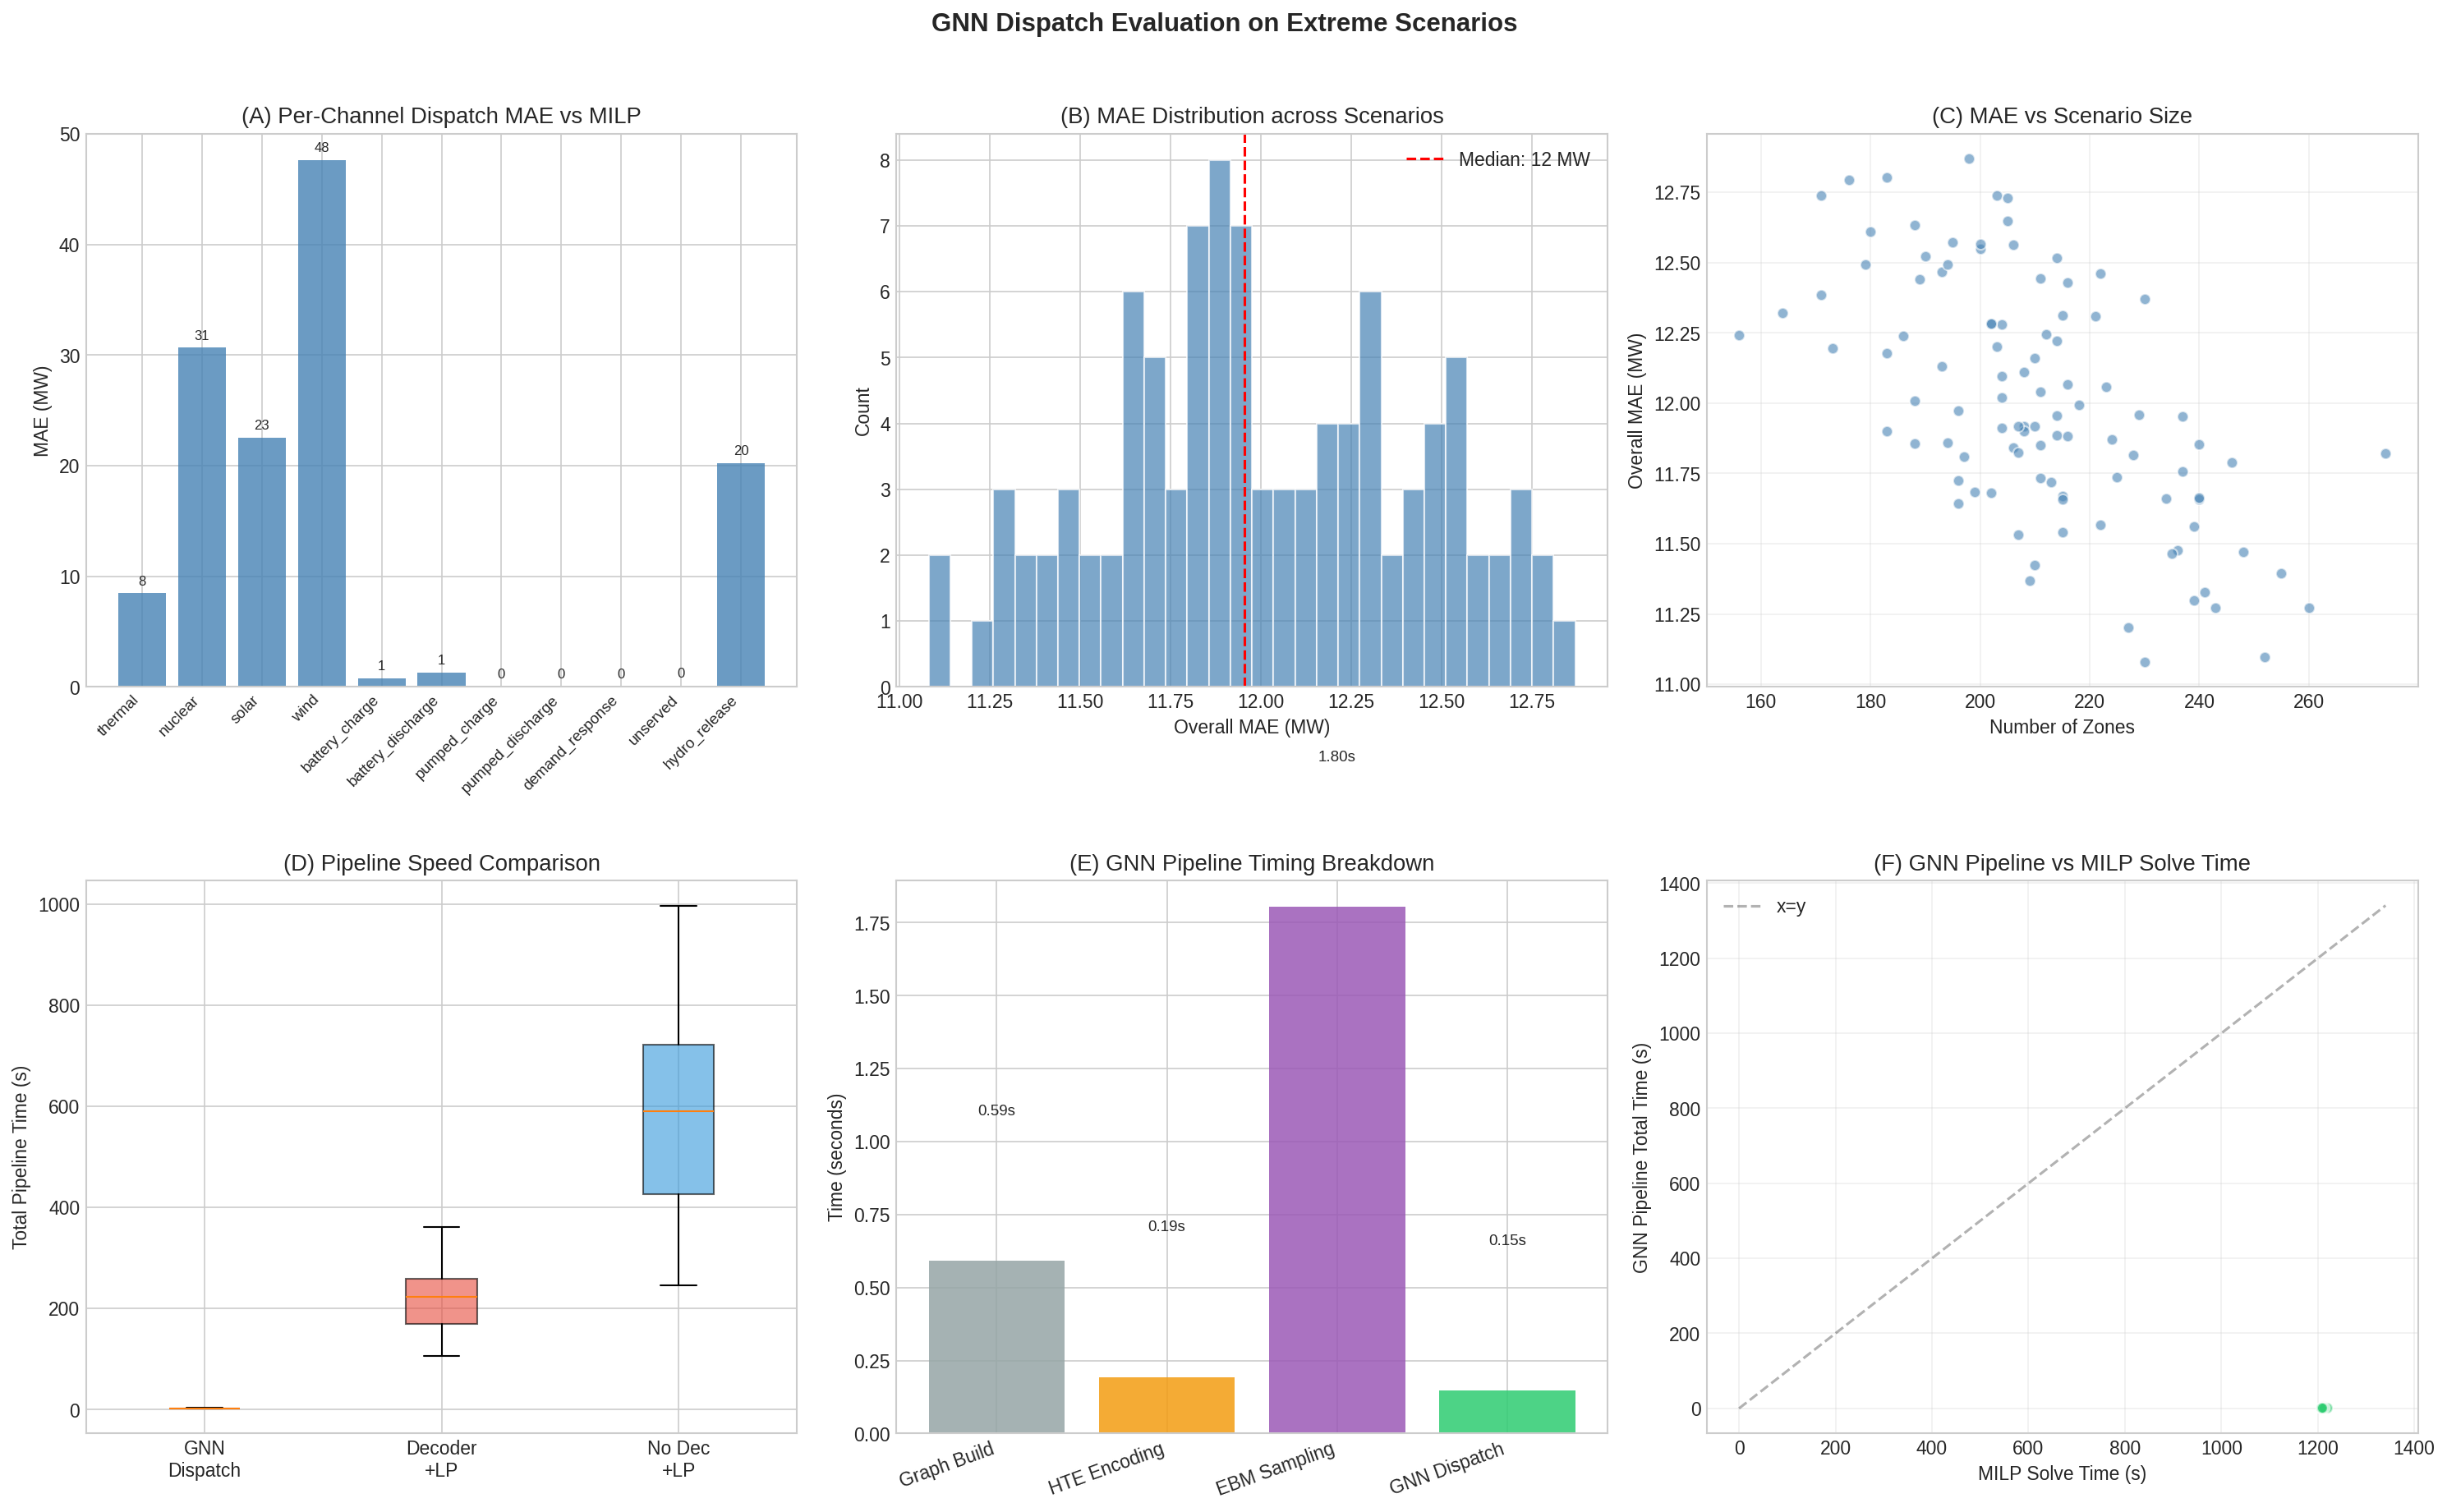

In [10]:
# ── Build comparison DataFrame ──
# GNN dispatch doesn't produce an LP objective, so we compare:
# 1. Dispatch MAE (quality of predicted dispatch vs MILP)
# 2. Pipeline speed (GNN vs Decoder+LP)
# 3. Per-channel accuracy

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ── Panel A: Per-channel MAE bar chart ──
ax = axes[0, 0]
channels = DISPATCH_CHANNELS
mae_means = [df_dispatch[f'mae_{ch}'].mean() for ch in channels]
bars = ax.bar(range(len(channels)), mae_means, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(channels)))
ax.set_xticklabels(channels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('MAE (MW)')
ax.set_title('(A) Per-Channel Dispatch MAE vs MILP')
for bar, val in zip(bars, mae_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# ── Panel B: MAE distribution per scenario ──
ax = axes[0, 1]
ax.hist(df_dispatch['mae_overall'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(x=df_dispatch['mae_overall'].median(), color='red', linestyle='--',
           label=f'Median: {df_dispatch["mae_overall"].median():.0f} MW')
ax.set_xlabel('Overall MAE (MW)')
ax.set_ylabel('Count')
ax.set_title('(B) MAE Distribution across Scenarios')
ax.legend()

# ── Panel C: MAE vs n_zones ──
ax = axes[0, 2]
ax.scatter(df_dispatch['n_zones'], df_dispatch['mae_overall'],
           c='steelblue', s=40, alpha=0.6, edgecolors='white')
ax.set_xlabel('Number of Zones')
ax.set_ylabel('Overall MAE (MW)')
ax.set_title('(C) MAE vs Scenario Size')
ax.grid(True, alpha=0.3)

# ── Panel D: Timing comparison ──
ax = axes[1, 0]
time_data = {'GNN\nDispatch': df_gnn['time_total'].values}
labels = ['GNN Dispatch']
colors_t = ['#2ecc71']
if HAS_BASELINE:
    time_data['Decoder\n+LP'] = df_bl['pipeline_solve_time'].values
    labels.append('Decoder+LP')
    colors_t.append('#e74c3c')
if HAS_ND:
    time_data['No Dec\n+LP'] = df_nd['pipeline_solve_time'].values
    labels.append('No Dec+LP')
    colors_t.append('#3498db')
bp = ax.boxplot(list(time_data.values()), labels=list(time_data.keys()),
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], colors_t):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Total Pipeline Time (s)')
ax.set_title('(D) Pipeline Speed Comparison')

# ── Panel E: Timing breakdown ──
ax = axes[1, 1]
gnn_means = [
    df_gnn['time_graph_build'].mean(),
    df_gnn['time_embedding'].mean(),
    df_gnn['time_ebm_sampling'].mean(),
    df_gnn['time_decoder'].mean() + df_gnn['time_lp_solve'].mean(),  # GNN dispatch time
]
stage_labels = ['Graph Build', 'HTE Encoding', 'EBM Sampling', 'GNN Dispatch']
colors_s = ['#95a5a6', '#f39c12', '#9b59b6', '#2ecc71']
ax.bar(stage_labels, gnn_means, color=colors_s, alpha=0.85)
for i, (lbl, val) in enumerate(zip(stage_labels, gnn_means)):
    ax.text(i, val + 0.5, f'{val:.2f}s', ha='center', fontsize=9)
ax.set_ylabel('Time (seconds)')
ax.set_title('(E) GNN Pipeline Timing Breakdown')
ax.set_xticklabels(stage_labels, rotation=20, ha='right')

# ── Panel F: GNN time vs MILP time scatter ──
ax = axes[1, 2]
ax.scatter(df_dispatch['milp_solve_time'], df_gnn['time_total'].values[:len(df_dispatch)],
           c='#2ecc71', s=40, alpha=0.6, edgecolors='white')
max_t = df_dispatch['milp_solve_time'].max() * 1.1
ax.plot([0, max_t], [0, max_t], 'k--', alpha=0.3, label='x=y')
ax.set_xlabel('MILP Solve Time (s)')
ax.set_ylabel('GNN Pipeline Total Time (s)')
ax.set_title('(F) GNN Pipeline vs MILP Solve Time')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('GNN Dispatch Evaluation on Extreme Scenarios',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_gnn_dispatch_extreme.png', dpi=300, bbox_inches='tight')
plt.show()

Scatter data:   0%|          | 0/50 [00:00<?, ?it/s]

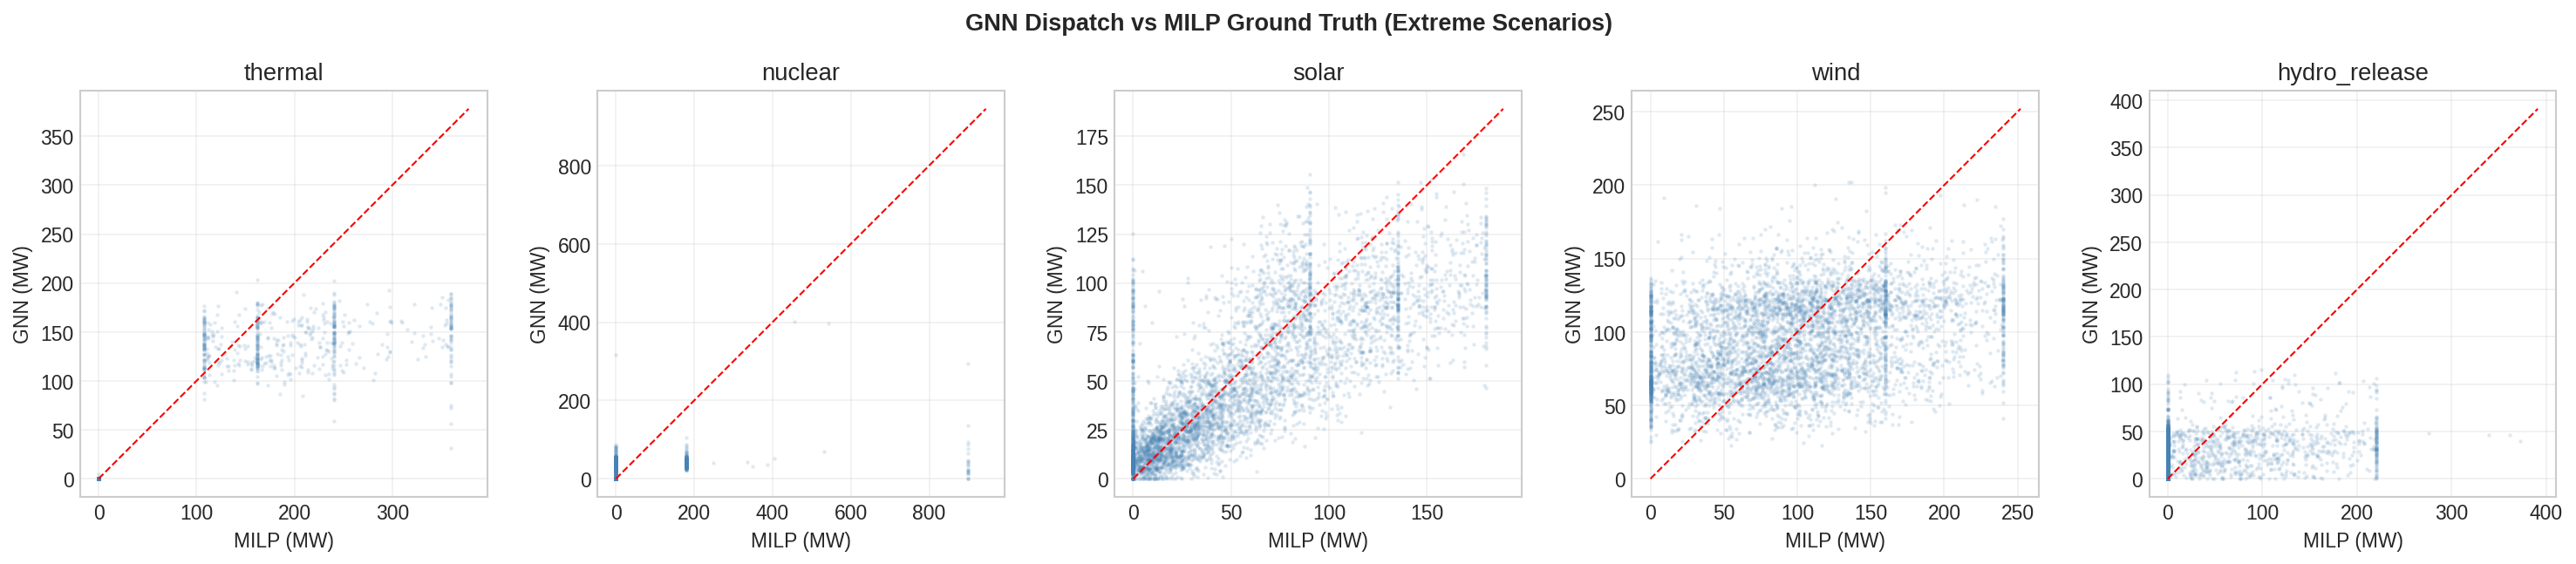

In [11]:
# ── Per-channel scatter: GNN prediction vs MILP ground truth ──
# Aggregate over all scenarios for key channels

key_channels = ['thermal', 'nuclear', 'solar', 'wind', 'hydro_release']
fig, axes = plt.subplots(1, len(key_channels), figsize=(4*len(key_channels), 4))

# Re-collect per-zone predictions for scatter
all_pred = {ch: [] for ch in key_channels}
all_true = {ch: [] for ch in key_channels}

for rpath in tqdm(list(REPORTS_DIR.glob('scenario_*.json'))[:50], desc='Scatter data'):
    sc_id = rpath.stem
    with open(rpath) as f:
        report = json.load(f)
    u_gt = extract_binaries_from_report(report, 24)
    disp_result = extract_dispatch_from_report(report, 24)
    if u_gt is None or disp_result is None:
        continue
    y_gt, zone_names = disp_result
    Z = u_gt.shape[0]

    graph_path = graphs_dir / 'extreme_gnn_dispatch' / f'{sc_id}.npz'
    if not graph_path.exists():
        continue
    try:
        zone_emb, n_zones, _ = runner._generate_embedding(str(graph_path))
    except:
        continue
    if zone_emb.shape[0] < Z:
        zone_emb = torch.nn.functional.pad(zone_emb, (0,0,0,0,0,Z-zone_emb.shape[0]))
    elif zone_emb.shape[0] > Z:
        zone_emb = zone_emb[:Z]

    zone_mask = torch.ones(Z)
    gnn_r = predictor.predict(u_bin=u_gt, h_zt=zone_emb, zone_mask=zone_mask, scenario_id=sc_id)

    for ch in key_channels:
        c_idx = DISPATCH_CHANNELS.index(ch)
        pred_vals = gnn_r.continuous_vars.get(ch, np.zeros((Z, 24)))
        true_vals = y_gt[:, :, c_idx].numpy()
        all_pred[ch].append(pred_vals.flatten())
        all_true[ch].append(true_vals.flatten())

for i, ch in enumerate(key_channels):
    ax = axes[i]
    p = np.concatenate(all_pred[ch])
    t = np.concatenate(all_true[ch])
    n_pts = min(5000, len(p))
    idx = np.random.choice(len(p), n_pts, replace=False)
    ax.scatter(t[idx], p[idx], alpha=0.1, s=2, c='steelblue')
    lim = max(t[idx].max(), p[idx].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlabel('MILP (MW)')
    ax.set_ylabel('GNN (MW)')
    ax.set_title(ch)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('GNN Dispatch vs MILP Ground Truth (Extreme Scenarios)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_scatter_extreme.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary

In [12]:
print('=' * 80)
print('GNN DISPATCH EVALUATION - EXTREME SCENARIOS')
print('=' * 80)

print(f'\nScenarios evaluated: {len(df_dispatch)}')
print(f'Success rate:        {df_gnn["success"].mean()*100:.1f}%')

print(f'\n--- Dispatch Accuracy (MAE vs MILP) ---')
print(f'  Overall:    {df_dispatch["mae_overall"].mean():.1f} +/- {df_dispatch["mae_overall"].std():.1f} MW')
print(f'  Median:     {df_dispatch["mae_overall"].median():.1f} MW')
for ch in DISPATCH_CHANNELS:
    col = f'mae_{ch}'
    if col in df_dispatch.columns:
        print(f'  {ch:>20s}: {df_dispatch[col].mean():.1f} MW')

print(f'\n--- Speed ---')
gnn_total = df_gnn['time_total'].mean()
gnn_dispatch_only = df_gnn['time_decoder'].mean() + df_gnn['time_lp_solve'].mean()
print(f'  GNN pipeline total:    {gnn_total:.2f}s/scenario')
print(f'  GNN dispatch only:     {gnn_dispatch_only*1000:.1f}ms/scenario')
if HAS_BASELINE:
    bl_total = df_bl['pipeline_solve_time'].mean()
    print(f'  Baseline (dec+LP):     {bl_total:.2f}s/scenario')
    print(f'  Speedup vs baseline:   {bl_total/gnn_total:.1f}x (total), '
          f'{(df_bl["time_decoder"].mean()+df_bl["time_lp_solve"].mean())/max(gnn_dispatch_only, 1e-6):.0f}x (dec+LP vs GNN)')

print(f'\n--- Files ---')
print(f'  Results:  {OUTPUT_DIR / "pipeline_eval_extreme_gnn_dispatch.pkl"}')
print(f'  Figures:  {OUTPUT_DIR / "fig1_gnn_dispatch_extreme.png"}')
print(f'  Figures:  {OUTPUT_DIR / "fig2_scatter_extreme.png"}')

# Save dispatch comparison as JSON
df_dispatch.to_json(OUTPUT_DIR / 'dispatch_mae_extreme.json', orient='records', indent=2)
print(f'  MAE data: {OUTPUT_DIR / "dispatch_mae_extreme.json"}')
print('=' * 80)

GNN DISPATCH EVALUATION - EXTREME SCENARIOS

Scenarios evaluated: 100
Success rate:        100.0%

--- Dispatch Accuracy (MAE vs MILP) ---
  Overall:    12.0 +/- 0.4 MW
  Median:     12.0 MW
               thermal: 8.5 MW
               nuclear: 30.7 MW
                 solar: 22.6 MW
                  wind: 47.6 MW
        battery_charge: 0.8 MW
     battery_discharge: 1.3 MW
         pumped_charge: 0.1 MW
      pumped_discharge: 0.1 MW
       demand_response: 0.1 MW
              unserved: 0.1 MW
         hydro_release: 20.2 MW

--- Speed ---
  GNN pipeline total:    2.74s/scenario
  GNN dispatch only:     146.4ms/scenario
  Baseline (dec+LP):     224.87s/scenario
  Speedup vs baseline:   82.2x (total), 1518x (dec+LP vs GNN)

--- Files ---
  Results:  /content/drive/MyDrive/benchmark/outputs/pipeline_eval_extreme_gnn_dispatch/pipeline_eval_extreme_gnn_dispatch.pkl
  Figures:  /content/drive/MyDrive/benchmark/outputs/pipeline_eval_extreme_gnn_dispatch/fig1_gnn_dispatch_extreme.png
  F

## 9. Cost Objective Comparison: GNN Dispatch vs MILP

Compute the **true operating cost** from GNN-predicted dispatch using the
scenario cost parameters (thermal/nuclear fuel, VOLL, battery/pumped cycle
costs, DR costs, spill costs). This gives a direct EUR comparison with
the MILP objective.

**Cost components** (matching the MILP objective in `model.py`):
- Thermal fuel cost: `thermal_cost[z] * p_thermal[z,t]`
- Nuclear fuel cost: `nuclear_cost[z] * p_nuclear[z,t]`
- Battery cycle cost: `battery_cycle_cost[z] * (charge + discharge)`
- Pumped cycle cost: `pumped_cycle_cost[z] * (charge + discharge)`
- Demand response cost: `dr_cost * dr_shed[z,t]` (simplified flat rate)
- Unserved energy cost: `VOLL * unserved[z,t]`
- Renewable spill cost: `res_spill_cost * (solar_spill + wind_spill)`

**Note**: We cannot compute startup costs or transmission/import/export
costs from GNN dispatch alone (no commitment binaries or flow variables),
so the GNN cost is a **lower bound** of the true objective.

In [13]:
from src.milp.scenario_loader import load_scenario_data

def compute_gnn_cost_objective(
    gnn_dispatch: dict,
    scenario_data,
    T: int = 24,
) -> dict:
    """
    Compute operating cost from GNN-predicted dispatch using scenario cost params.

    Args:
        gnn_dispatch: dict[channel_name -> np.ndarray of shape [Z, T]]
        scenario_data: ScenarioData from load_scenario_data
        T: number of timesteps

    Returns:
        dict with per-component and total cost (EUR)
    """
    zones = scenario_data.zones
    Z = len(zones)
    dt = scenario_data.dt_hours

    thermal   = gnn_dispatch.get('thermal', np.zeros((Z, T)))
    nuclear   = gnn_dispatch.get('nuclear', np.zeros((Z, T)))
    solar     = gnn_dispatch.get('solar', np.zeros((Z, T)))
    wind      = gnn_dispatch.get('wind', np.zeros((Z, T)))
    batt_ch   = gnn_dispatch.get('battery_charge', np.zeros((Z, T)))
    batt_dis  = gnn_dispatch.get('battery_discharge', np.zeros((Z, T)))
    pump_ch   = gnn_dispatch.get('pumped_charge', np.zeros((Z, T)))
    pump_dis  = gnn_dispatch.get('pumped_discharge', np.zeros((Z, T)))
    dr_shed   = gnn_dispatch.get('demand_response', np.zeros((Z, T)))
    unserved  = gnn_dispatch.get('unserved', np.zeros((Z, T)))
    hydro_rel = gnn_dispatch.get('hydro_release', np.zeros((Z, T)))

    # ── Cost components ──
    thermal_fuel = 0.0
    nuclear_fuel = 0.0
    battery_cycle = 0.0
    pumped_cycle = 0.0
    dr_cost_total = 0.0
    unserved_cost = 0.0

    voll = scenario_data.voll
    dr_cost_rate = scenario_data.dr_cost_per_mwh

    for zi, z in enumerate(zones):
        if zi >= Z:
            break
        tc = scenario_data.thermal_cost.get(z, 0.0)
        nc = scenario_data.nuclear_cost.get(z, 0.0)
        bc = scenario_data.battery_cycle_cost.get(z, 0.0)
        pc = scenario_data.pumped_cycle_cost.get(z, 0.0)

        for t in range(T):
            thermal_fuel  += tc * float(thermal[zi, t]) * dt
            nuclear_fuel  += nc * float(nuclear[zi, t]) * dt
            battery_cycle += bc * (float(batt_ch[zi, t]) + float(batt_dis[zi, t])) * dt
            pumped_cycle  += pc * (float(pump_ch[zi, t]) + float(pump_dis[zi, t])) * dt
            dr_cost_total += dr_cost_rate * float(dr_shed[zi, t]) * dt
            unserved_cost += voll * float(unserved[zi, t]) * dt

    # Renewable spill: solar_available - solar_dispatched, wind_available - wind_dispatched
    # We don't have explicit spill variables, but can estimate from curtailment
    spill_cost = scenario_data.variable_spill_cost
    solar_spill_total = 0.0
    wind_spill_total = 0.0
    for zi, z in enumerate(zones):
        if zi >= Z:
            break
        for t in range(T):
            sa = scenario_data.solar_available.get((z, t), 0.0)
            wa = scenario_data.wind_available.get((z, t), 0.0)
            solar_curtailed = max(0.0, sa - float(solar[zi, t]))
            wind_curtailed = max(0.0, wa - float(wind[zi, t]))
            solar_spill_total += spill_cost * solar_curtailed * dt
            wind_spill_total  += spill_cost * wind_curtailed * dt

    total = (thermal_fuel + nuclear_fuel + battery_cycle + pumped_cycle
             + dr_cost_total + unserved_cost + solar_spill_total + wind_spill_total)

    return {
        'thermal_fuel': thermal_fuel,
        'nuclear_fuel': nuclear_fuel,
        'battery_cycle': battery_cycle,
        'pumped_cycle': pumped_cycle,
        'demand_response': dr_cost_total,
        'unserved_energy': unserved_cost,
        'solar_spill': solar_spill_total,
        'wind_spill': wind_spill_total,
        'total': total,
    }


# ── Compute GNN cost objective for each extreme scenario ──
cost_results = []

for rpath in tqdm(report_files, desc='Cost Objective'):
    sc_id = rpath.stem
    sc_path = scenario_files.get(sc_id)
    if sc_path is None:
        continue

    # Load scenario data (cost parameters)
    try:
        sc_data = load_scenario_data(sc_path)
    except Exception as e:
        print(f'  Skip {sc_id}: scenario load error: {e}')
        continue

    # Load MILP report for ground truth objective
    with open(rpath) as f:
        report = json.load(f)
    milp_obj = report.get('mip', {}).get('objective', None)
    if milp_obj is None:
        continue

    # Extract GT binaries and dispatch for GNN prediction
    u_gt = extract_binaries_from_report(report, 24)
    disp_result = extract_dispatch_from_report(report, 24)
    if u_gt is None or disp_result is None:
        continue
    y_gt, zone_names = disp_result
    Z = u_gt.shape[0]

    # Generate embedding
    graph_path = graphs_dir / 'extreme_gnn_dispatch' / f'{sc_id}.npz'
    if not graph_path.exists():
        continue
    try:
        zone_emb, n_zones, _ = runner._generate_embedding(str(graph_path))
    except:
        continue
    if zone_emb.shape[0] < Z:
        zone_emb = torch.nn.functional.pad(zone_emb, (0,0,0,0,0,Z-zone_emb.shape[0]))
    elif zone_emb.shape[0] > Z:
        zone_emb = zone_emb[:Z]

    # GNN prediction (teacher-forced with GT binaries)
    zone_mask = torch.ones(Z)
    gnn_result = predictor.predict(
        u_bin=u_gt, h_zt=zone_emb, zone_mask=zone_mask,
        zone_names=zone_names, scenario_id=sc_id,
    )

    # Compute GNN cost
    gnn_costs = compute_gnn_cost_objective(gnn_result.continuous_vars, sc_data, T=24)

    # Compute MILP cost from GT dispatch for comparison
    milp_dispatch = {}
    for c_idx, ch in enumerate(DISPATCH_CHANNELS):
        milp_dispatch[ch] = y_gt[:, :, c_idx].numpy()
    milp_costs = compute_gnn_cost_objective(milp_dispatch, sc_data, T=24)

    cost_results.append({
        'scenario_id': sc_id,
        'n_zones': Z,
        'milp_objective': milp_obj,
        'milp_recomputed': milp_costs['total'],
        'gnn_objective': gnn_costs['total'],
        'cost_gap_pct': 100.0 * (gnn_costs['total'] - milp_obj) / abs(milp_obj) if milp_obj != 0 else 0,
        **{f'gnn_{k}': v for k, v in gnn_costs.items() if k != 'total'},
        **{f'milp_{k}': v for k, v in milp_costs.items() if k != 'total'},
    })

df_cost = pd.DataFrame(cost_results)
print(f'\nCost comparison: {len(df_cost)} scenarios')
print(f'\nMILP objective (mean):      {df_cost["milp_objective"].mean():,.0f} EUR')
print(f'MILP recomputed (mean):     {df_cost["milp_recomputed"].mean():,.0f} EUR')
print(f'GNN objective (mean):       {df_cost["gnn_objective"].mean():,.0f} EUR')
print(f'Cost gap vs MILP (median):  {df_cost["cost_gap_pct"].median():.1f}%')
print(f'Cost gap vs MILP (mean):    {df_cost["cost_gap_pct"].mean():.1f}%')

Cost Objective:   0%|          | 0/100 [00:00<?, ?it/s]


Cost comparison: 100 scenarios

MILP objective (mean):      -25,092,083 EUR
MILP recomputed (mean):     27,075,312 EUR
GNN objective (mean):       33,241,751 EUR
Cost gap vs MILP (median):  183.8%
Cost gap vs MILP (mean):    522.7%


/tmp/ipykernel_1843/2959486872.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp_labels, rotation=45, ha='right', fontsize=9)


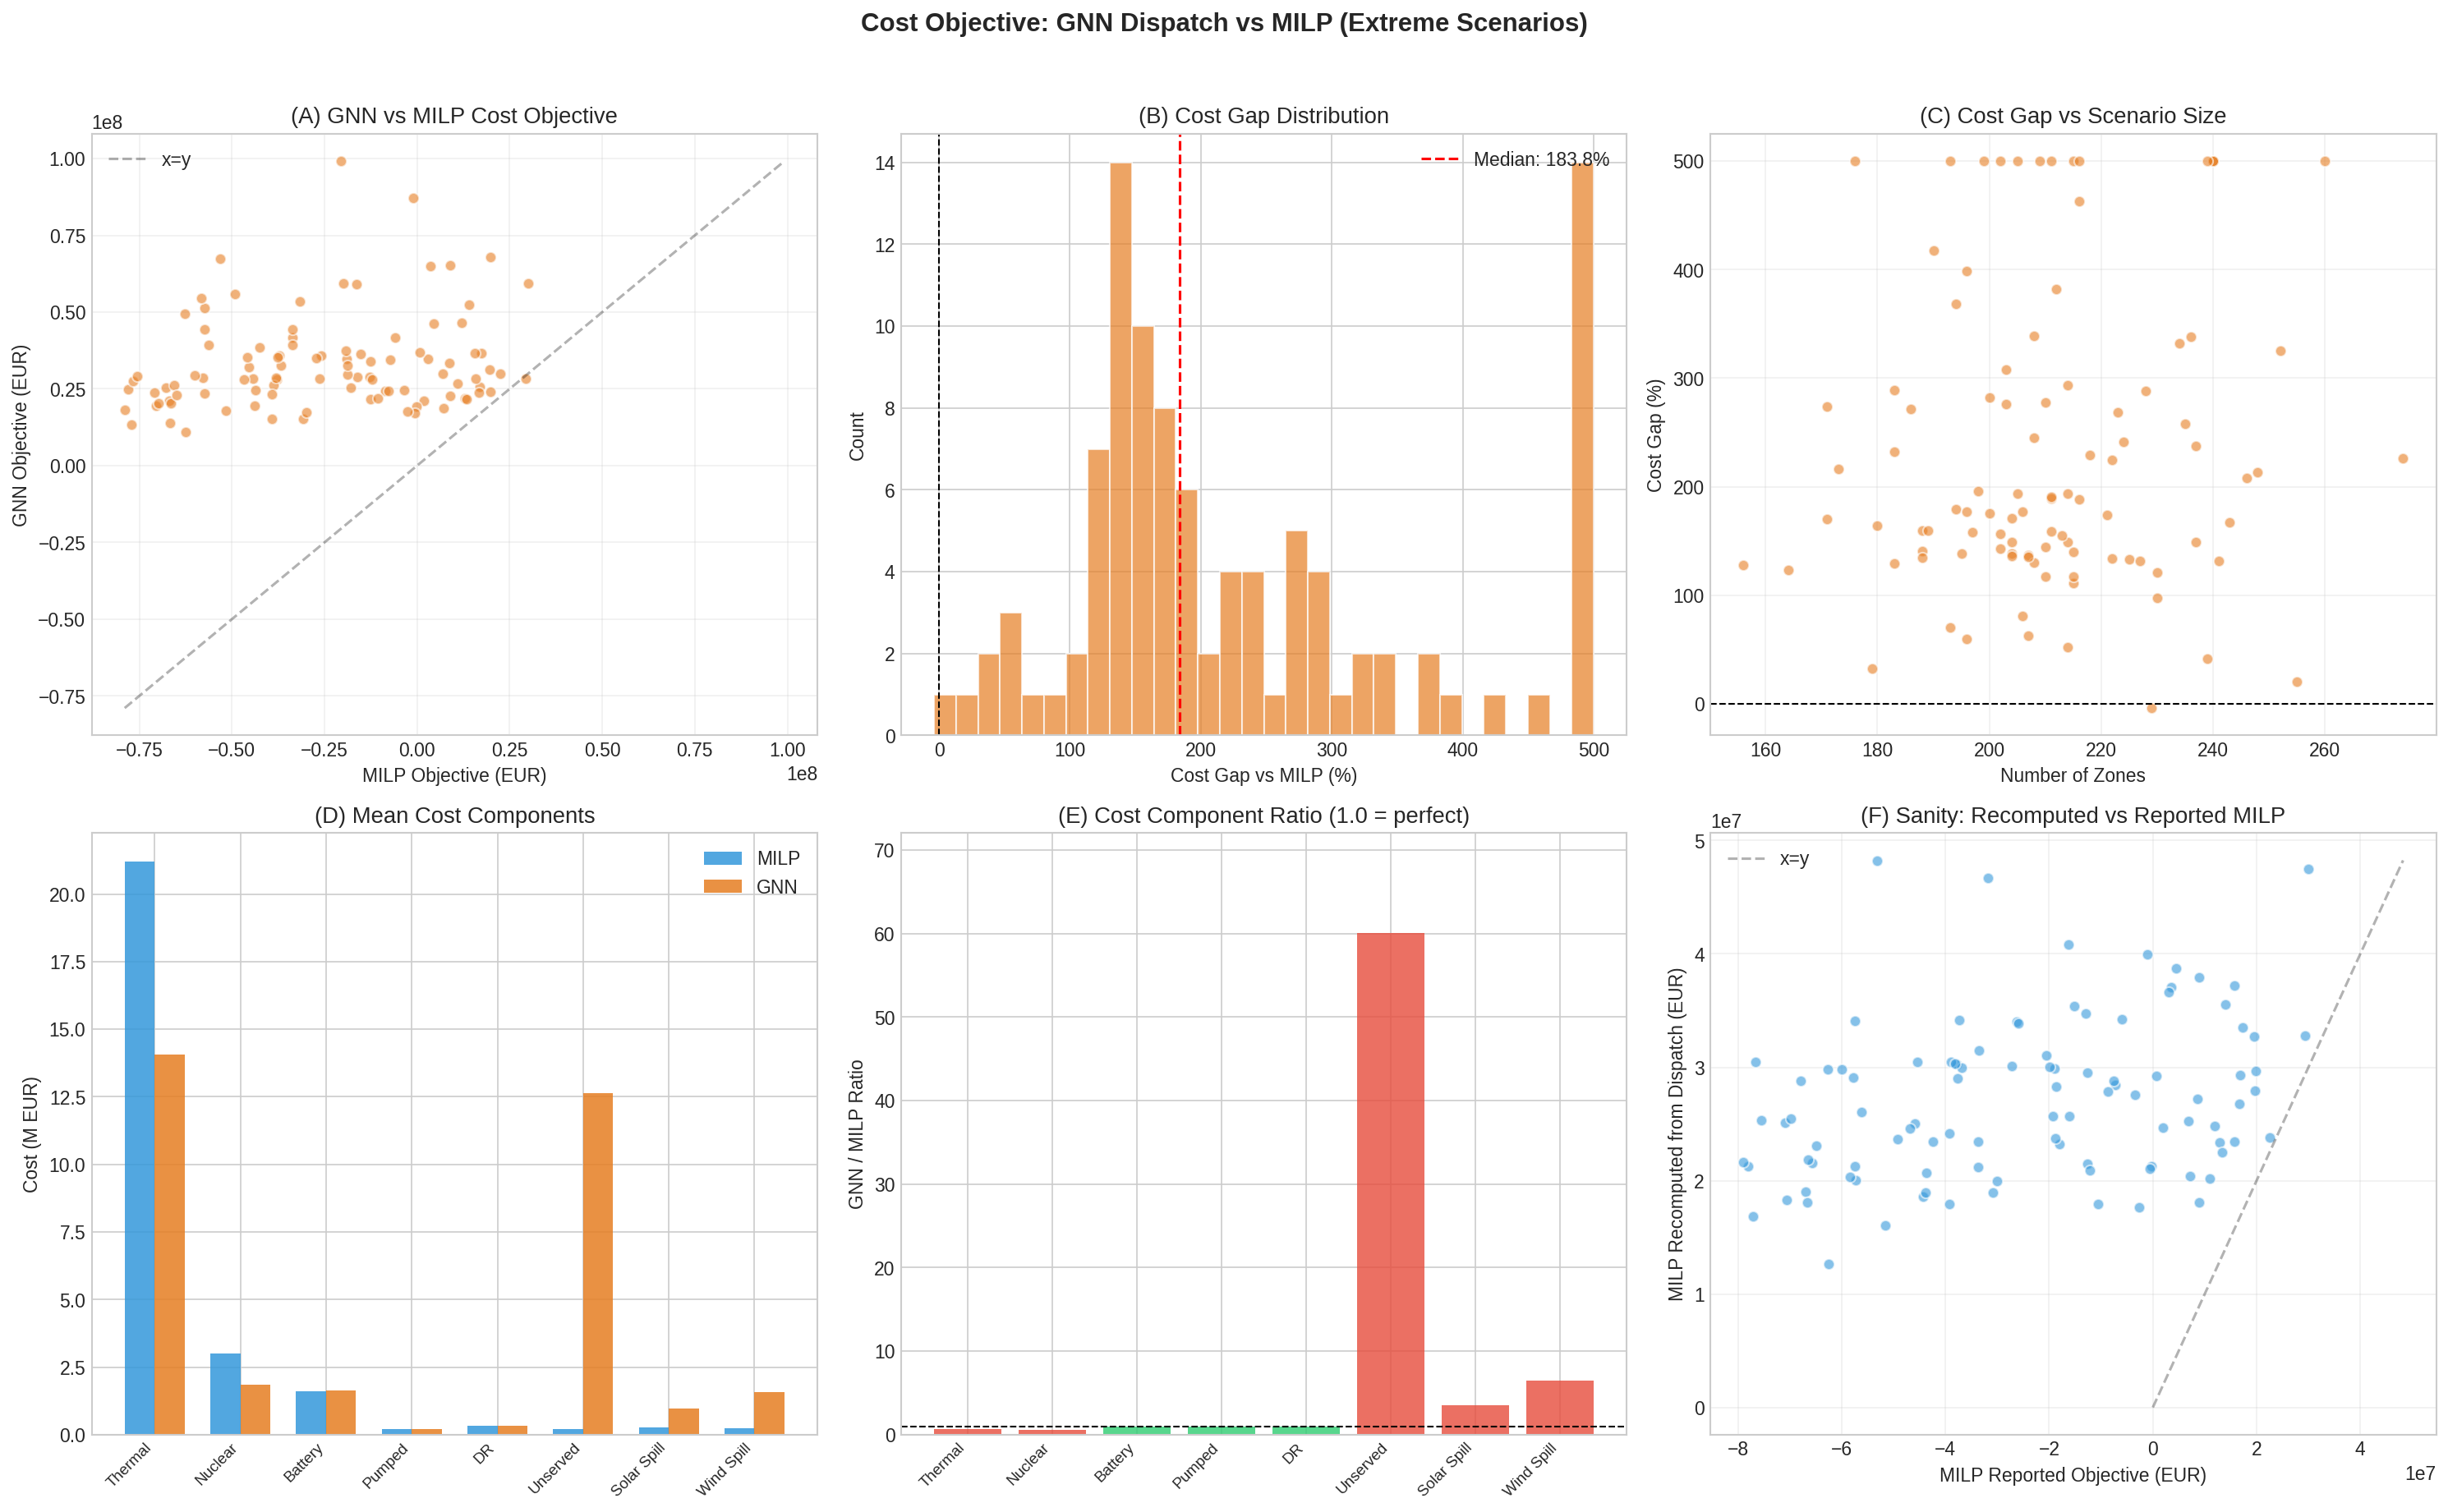


Component              MILP (MEUR)    GNN (MEUR)     Ratio
----------------------------------------------------------
Thermal                      21.20         14.06      0.66
Nuclear                       3.01          1.85      0.61
Battery                       1.62          1.63      1.00
Pumped                        0.20          0.20      1.03
DR                            0.32          0.33      1.02
Unserved                      0.21         12.63     60.02
Solar Spill                   0.27          0.96      3.54
Wind Spill                    0.24          1.58      6.49


In [14]:
# ── Cost Objective Visualisation ──

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ── Panel A: GNN objective vs MILP objective scatter ──
ax = axes[0, 0]
ax.scatter(df_cost['milp_objective'], df_cost['gnn_objective'],
           c='#e67e22', s=40, alpha=0.6, edgecolors='white')
obj_min = min(df_cost['milp_objective'].min(), df_cost['gnn_objective'].min())
obj_max = max(df_cost['milp_objective'].max(), df_cost['gnn_objective'].max())
ax.plot([obj_min, obj_max], [obj_min, obj_max], 'k--', alpha=0.3, label='x=y')
ax.set_xlabel('MILP Objective (EUR)')
ax.set_ylabel('GNN Objective (EUR)')
ax.set_title('(A) GNN vs MILP Cost Objective')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Panel B: Cost gap distribution ──
ax = axes[0, 1]
gaps = df_cost['cost_gap_pct'].clip(-200, 500)
ax.hist(gaps, bins=30, color='#e67e22', alpha=0.7, edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', lw=1)
ax.axvline(x=gaps.median(), color='red', linestyle='--',
           label=f'Median: {gaps.median():.1f}%')
ax.set_xlabel('Cost Gap vs MILP (%)')
ax.set_ylabel('Count')
ax.set_title('(B) Cost Gap Distribution')
ax.legend()

# ── Panel C: Cost gap vs scenario size ──
ax = axes[0, 2]
ax.scatter(df_cost['n_zones'], df_cost['cost_gap_pct'].clip(-200, 500),
           c='#e67e22', s=40, alpha=0.6, edgecolors='white')
ax.axhline(y=0, color='black', linestyle='--', lw=1)
ax.set_xlabel('Number of Zones')
ax.set_ylabel('Cost Gap (%)')
ax.set_title('(C) Cost Gap vs Scenario Size')
ax.grid(True, alpha=0.3)

# ── Panel D: Cost component breakdown - GNN vs MILP (mean) ──
ax = axes[1, 0]
components = ['thermal_fuel', 'nuclear_fuel', 'battery_cycle', 'pumped_cycle',
              'demand_response', 'unserved_energy', 'solar_spill', 'wind_spill']
comp_labels = ['Thermal', 'Nuclear', 'Battery', 'Pumped',
               'DR', 'Unserved', 'Solar Spill', 'Wind Spill']
gnn_means = [df_cost[f'gnn_{c}'].mean() for c in components]
milp_means = [df_cost[f'milp_{c}'].mean() for c in components]

x = np.arange(len(comp_labels))
w = 0.35
bars1 = ax.bar(x - w/2, [v/1e6 for v in milp_means], w, label='MILP', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, [v/1e6 for v in gnn_means], w, label='GNN', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(comp_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Cost (M EUR)')
ax.set_title('(D) Mean Cost Components')
ax.legend()

# ── Panel E: Ratio of each component GNN/MILP ──
ax = axes[1, 1]
ratios = []
for c in components:
    gnn_v = df_cost[f'gnn_{c}'].mean()
    milp_v = df_cost[f'milp_{c}'].mean()
    ratios.append(gnn_v / milp_v if milp_v > 1e-3 else 1.0)
colors_r = ['#2ecc71' if 0.8 <= r <= 1.2 else '#e74c3c' for r in ratios]
ax.bar(comp_labels, ratios, color=colors_r, alpha=0.8)
ax.axhline(y=1.0, color='black', linestyle='--', lw=1)
ax.set_ylabel('GNN / MILP Ratio')
ax.set_title('(E) Cost Component Ratio (1.0 = perfect)')
ax.set_xticklabels(comp_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, max(ratios) * 1.2)

# ── Panel F: Recomputed MILP vs reported MILP objective ──
ax = axes[1, 2]
ax.scatter(df_cost['milp_objective'], df_cost['milp_recomputed'],
           c='#3498db', s=40, alpha=0.6, edgecolors='white')
obj_r = max(df_cost['milp_objective'].max(), df_cost['milp_recomputed'].max())
ax.plot([0, obj_r], [0, obj_r], 'k--', alpha=0.3, label='x=y')
ax.set_xlabel('MILP Reported Objective (EUR)')
ax.set_ylabel('MILP Recomputed from Dispatch (EUR)')
ax.set_title('(F) Sanity: Recomputed vs Reported MILP')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Cost Objective: GNN Dispatch vs MILP (Extreme Scenarios)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_cost_objective.png', dpi=300, bbox_inches='tight')
plt.show()

# Print component-wise comparison
print(f'\n{"Component":<20s}  {"MILP (MEUR)":>12s}  {"GNN (MEUR)":>12s}  {"Ratio":>8s}')
print('-' * 58)
for c, lbl in zip(components, comp_labels):
    gv = df_cost[f'gnn_{c}'].mean()
    mv = df_cost[f'milp_{c}'].mean()
    r = gv / mv if mv > 1e-3 else float('nan')
    print(f'{lbl:<20s}  {mv/1e6:>12.2f}  {gv/1e6:>12.2f}  {r:>8.2f}')

## 10. Feasibility Analysis: Does GNN Dispatch Satisfy Physical Constraints?

Check key physical constraints that the MILP enforces:

1. **Demand balance**: `generation + DR + unserved >= demand + storage_charge` per zone per timestep
2. **Thermal capacity**: `0 <= thermal[z,t] <= thermal_capacity[z]`
3. **Nuclear capacity**: `nuclear_min[z] <= nuclear[z,t] <= nuclear_capacity[z]`
4. **Solar/wind availability**: `solar[z,t] <= solar_available[z,t]`, `wind[z,t] <= wind_available[z,t]`
5. **Battery power limits**: `charge <= battery_power[z]`, `discharge <= battery_power[z]`
6. **Pumped power limits**: `charge <= pumped_power[z]`, `discharge <= pumped_power[z]`
7. **DR limits**: `dr_shed[z,t] <= dr_limit[z,t]`
8. **Non-negativity**: all dispatch values >= 0

In [15]:
def check_feasibility(
    gnn_dispatch: dict,
    scenario_data,
    T: int = 24,
    tol: float = 1.0,
) -> dict:
    """
    Check physical feasibility of GNN-predicted dispatch.

    Args:
        gnn_dispatch: dict[channel_name -> np.ndarray [Z, T]]
        scenario_data: ScenarioData
        T: timesteps
        tol: tolerance in MW for constraint violations

    Returns:
        dict with violation counts and magnitudes per constraint type
    """
    zones = scenario_data.zones
    Z = len(zones)

    thermal   = gnn_dispatch.get('thermal', np.zeros((Z, T)))
    nuclear   = gnn_dispatch.get('nuclear', np.zeros((Z, T)))
    solar     = gnn_dispatch.get('solar', np.zeros((Z, T)))
    wind      = gnn_dispatch.get('wind', np.zeros((Z, T)))
    batt_ch   = gnn_dispatch.get('battery_charge', np.zeros((Z, T)))
    batt_dis  = gnn_dispatch.get('battery_discharge', np.zeros((Z, T)))
    pump_ch   = gnn_dispatch.get('pumped_charge', np.zeros((Z, T)))
    pump_dis  = gnn_dispatch.get('pumped_discharge', np.zeros((Z, T)))
    dr_shed   = gnn_dispatch.get('demand_response', np.zeros((Z, T)))
    unserved  = gnn_dispatch.get('unserved', np.zeros((Z, T)))
    hydro_rel = gnn_dispatch.get('hydro_release', np.zeros((Z, T)))

    violations = {
        'demand_balance': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'thermal_capacity': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'nuclear_capacity': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'nuclear_minimum': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'solar_availability': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'wind_availability': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'battery_power': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'pumped_power': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'dr_limit': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
        'non_negativity': {'count': 0, 'total_mw': 0.0, 'max_mw': 0.0},
    }

    total_checks = 0

    for zi, z in enumerate(zones):
        if zi >= Z:
            break

        th_cap = scenario_data.thermal_capacity.get(z, 0.0)
        nuc_cap = scenario_data.nuclear_capacity.get(z, 0.0)
        nuc_min = scenario_data.nuclear_min_power.get(z, 0.0)
        bp = scenario_data.battery_power.get(z, 0.0)
        pp = scenario_data.pumped_power.get(z, 0.0)
        hcap = scenario_data.hydro_res_capacity.get(z, 0.0)

        for t in range(T):
            total_checks += 1

            # ── Demand balance ──
            demand = scenario_data.demand.get((z, t), 0.0)
            ror = scenario_data.hydro_ror_generation.get((z, t), 0.0)
            generation = (
                float(thermal[zi, t]) + float(nuclear[zi, t])
                + float(solar[zi, t]) + float(wind[zi, t])
                + float(hydro_rel[zi, t]) + ror
                + float(batt_dis[zi, t]) + float(pump_dis[zi, t])
                + float(dr_shed[zi, t]) + float(unserved[zi, t])
            )
            load = demand + float(batt_ch[zi, t]) + float(pump_ch[zi, t])
            imbalance = load - generation
            if imbalance > tol:
                violations['demand_balance']['count'] += 1
                violations['demand_balance']['total_mw'] += imbalance
                violations['demand_balance']['max_mw'] = max(
                    violations['demand_balance']['max_mw'], imbalance)

            # ── Thermal capacity ──
            th_val = float(thermal[zi, t])
            if th_val > th_cap + tol:
                v = th_val - th_cap
                violations['thermal_capacity']['count'] += 1
                violations['thermal_capacity']['total_mw'] += v
                violations['thermal_capacity']['max_mw'] = max(
                    violations['thermal_capacity']['max_mw'], v)

            # ── Nuclear capacity ──
            nuc_val = float(nuclear[zi, t])
            if nuc_val > nuc_cap + tol:
                v = nuc_val - nuc_cap
                violations['nuclear_capacity']['count'] += 1
                violations['nuclear_capacity']['total_mw'] += v
                violations['nuclear_capacity']['max_mw'] = max(
                    violations['nuclear_capacity']['max_mw'], v)

            # ── Nuclear minimum ──
            if nuc_cap > 1e-6 and nuc_val < nuc_min - tol:
                v = nuc_min - nuc_val
                violations['nuclear_minimum']['count'] += 1
                violations['nuclear_minimum']['total_mw'] += v
                violations['nuclear_minimum']['max_mw'] = max(
                    violations['nuclear_minimum']['max_mw'], v)

            # ── Solar availability ──
            sa = scenario_data.solar_available.get((z, t), 0.0)
            sol_val = float(solar[zi, t])
            if sol_val > sa + tol:
                v = sol_val - sa
                violations['solar_availability']['count'] += 1
                violations['solar_availability']['total_mw'] += v
                violations['solar_availability']['max_mw'] = max(
                    violations['solar_availability']['max_mw'], v)

            # ── Wind availability ──
            wa = scenario_data.wind_available.get((z, t), 0.0)
            wnd_val = float(wind[zi, t])
            if wnd_val > wa + tol:
                v = wnd_val - wa
                violations['wind_availability']['count'] += 1
                violations['wind_availability']['total_mw'] += v
                violations['wind_availability']['max_mw'] = max(
                    violations['wind_availability']['max_mw'], v)

            # ── Battery power ──
            bc = float(batt_ch[zi, t])
            bd = float(batt_dis[zi, t])
            for bv in [bc, bd]:
                if bv > bp + tol:
                    v = bv - bp
                    violations['battery_power']['count'] += 1
                    violations['battery_power']['total_mw'] += v
                    violations['battery_power']['max_mw'] = max(
                        violations['battery_power']['max_mw'], v)

            # ── Pumped power ──
            pc = float(pump_ch[zi, t])
            pd_val = float(pump_dis[zi, t])
            for pv in [pc, pd_val]:
                if pv > pp + tol:
                    v = pv - pp
                    violations['pumped_power']['count'] += 1
                    violations['pumped_power']['total_mw'] += v
                    violations['pumped_power']['max_mw'] = max(
                        violations['pumped_power']['max_mw'], v)

            # ── DR limit ──
            dr_lim = scenario_data.dr_limit.get((z, t), 0.0)
            dr_val = float(dr_shed[zi, t])
            if dr_val > dr_lim + tol:
                v = dr_val - dr_lim
                violations['dr_limit']['count'] += 1
                violations['dr_limit']['total_mw'] += v
                violations['dr_limit']['max_mw'] = max(
                    violations['dr_limit']['max_mw'], v)

            # ── Non-negativity ──
            for arr in [thermal, nuclear, solar, wind, batt_ch, batt_dis,
                        pump_ch, pump_dis, dr_shed, unserved, hydro_rel]:
                val = float(arr[zi, t])
                if val < -tol:
                    violations['non_negativity']['count'] += 1
                    violations['non_negativity']['total_mw'] += abs(val)
                    violations['non_negativity']['max_mw'] = max(
                        violations['non_negativity']['max_mw'], abs(val))

    violations['_total_checks'] = total_checks
    return violations


# ── Run feasibility check on all extreme scenarios ──
feasibility_results = []

for rpath in tqdm(report_files, desc='Feasibility Check'):
    sc_id = rpath.stem
    sc_path = scenario_files.get(sc_id)
    if sc_path is None:
        continue

    try:
        sc_data = load_scenario_data(sc_path)
    except:
        continue

    with open(rpath) as f:
        report = json.load(f)
    u_gt = extract_binaries_from_report(report, 24)
    disp_result = extract_dispatch_from_report(report, 24)
    if u_gt is None or disp_result is None:
        continue
    y_gt, zone_names = disp_result
    Z = u_gt.shape[0]

    graph_path = graphs_dir / 'extreme_gnn_dispatch' / f'{sc_id}.npz'
    if not graph_path.exists():
        continue
    try:
        zone_emb, n_zones, _ = runner._generate_embedding(str(graph_path))
    except:
        continue
    if zone_emb.shape[0] < Z:
        zone_emb = torch.nn.functional.pad(zone_emb, (0,0,0,0,0,Z-zone_emb.shape[0]))
    elif zone_emb.shape[0] > Z:
        zone_emb = zone_emb[:Z]

    zone_mask = torch.ones(Z)
    gnn_r = predictor.predict(u_bin=u_gt, h_zt=zone_emb, zone_mask=zone_mask,
                              zone_names=zone_names, scenario_id=sc_id)

    # Check GNN dispatch feasibility
    gnn_feas = check_feasibility(gnn_r.continuous_vars, sc_data, T=24, tol=1.0)

    # Check MILP dispatch feasibility (sanity - should be near-perfect)
    milp_dispatch = {ch: y_gt[:, :, c_idx].numpy() for c_idx, ch in enumerate(DISPATCH_CHANNELS)}
    milp_feas = check_feasibility(milp_dispatch, sc_data, T=24, tol=1.0)

    row = {'scenario_id': sc_id, 'n_zones': Z}
    for key in gnn_feas:
        if key.startswith('_'):
            row['total_checks'] = gnn_feas[key]
            continue
        row[f'gnn_{key}_count'] = gnn_feas[key]['count']
        row[f'gnn_{key}_max_mw'] = gnn_feas[key]['max_mw']
        row[f'milp_{key}_count'] = milp_feas[key]['count']
        row[f'milp_{key}_max_mw'] = milp_feas[key]['max_mw']
    feasibility_results.append(row)

df_feas = pd.DataFrame(feasibility_results)
print(f'\nFeasibility analysis: {len(df_feas)} scenarios')

# Summary table
constraint_types = ['demand_balance', 'thermal_capacity', 'nuclear_capacity',
                    'nuclear_minimum', 'solar_availability', 'wind_availability',
                    'battery_power', 'pumped_power', 'dr_limit', 'non_negativity']

print(f'\n{"Constraint":<22s}  {"GNN Violations":>14s}  {"GNN Max (MW)":>12s}  '
      f'{"MILP Violations":>15s}  {"MILP Max (MW)":>12s}')
print('-' * 82)
for ct in constraint_types:
    gnn_v = df_feas[f'gnn_{ct}_count'].sum()
    gnn_m = df_feas[f'gnn_{ct}_max_mw'].max()
    milp_v = df_feas[f'milp_{ct}_count'].sum()
    milp_m = df_feas[f'milp_{ct}_max_mw'].max()
    flag = ' ***' if gnn_v > 0 else ''
    print(f'{ct:<22s}  {gnn_v:>14d}  {gnn_m:>12.1f}  {milp_v:>15d}  {milp_m:>12.1f}{flag}')

total_gnn = sum(df_feas[f'gnn_{ct}_count'].sum() for ct in constraint_types)
total_milp = sum(df_feas[f'milp_{ct}_count'].sum() for ct in constraint_types)
total_checks = df_feas['total_checks'].sum()
print(f'\nTotal violations:  GNN={total_gnn:,}  MILP={total_milp:,}  '
      f'out of {total_checks:,} zone-timestep checks')
print(f'GNN feasibility rate: {100*(1 - total_gnn / max(total_checks*len(constraint_types), 1)):.1f}%')

Feasibility Check:   0%|          | 0/100 [00:00<?, ?it/s]


Feasibility analysis: 100 scenarios

Constraint              GNN Violations  GNN Max (MW)  MILP Violations  MILP Max (MW)
----------------------------------------------------------------------------------
demand_balance                  317227         332.8           242313         375.9 ***
thermal_capacity                     0           0.0                0           0.0
nuclear_capacity                139161         705.8                0           0.0 ***
nuclear_minimum                  59280         180.0                0           0.0 ***
solar_availability              193982          94.5                0           0.0 ***
wind_availability               234710         201.5                0           0.0 ***
battery_power                       97          25.3                0           0.0 ***
pumped_power                       238           9.6                0           0.0 ***
dr_limit                             0           0.0                0           0.0
non_negati

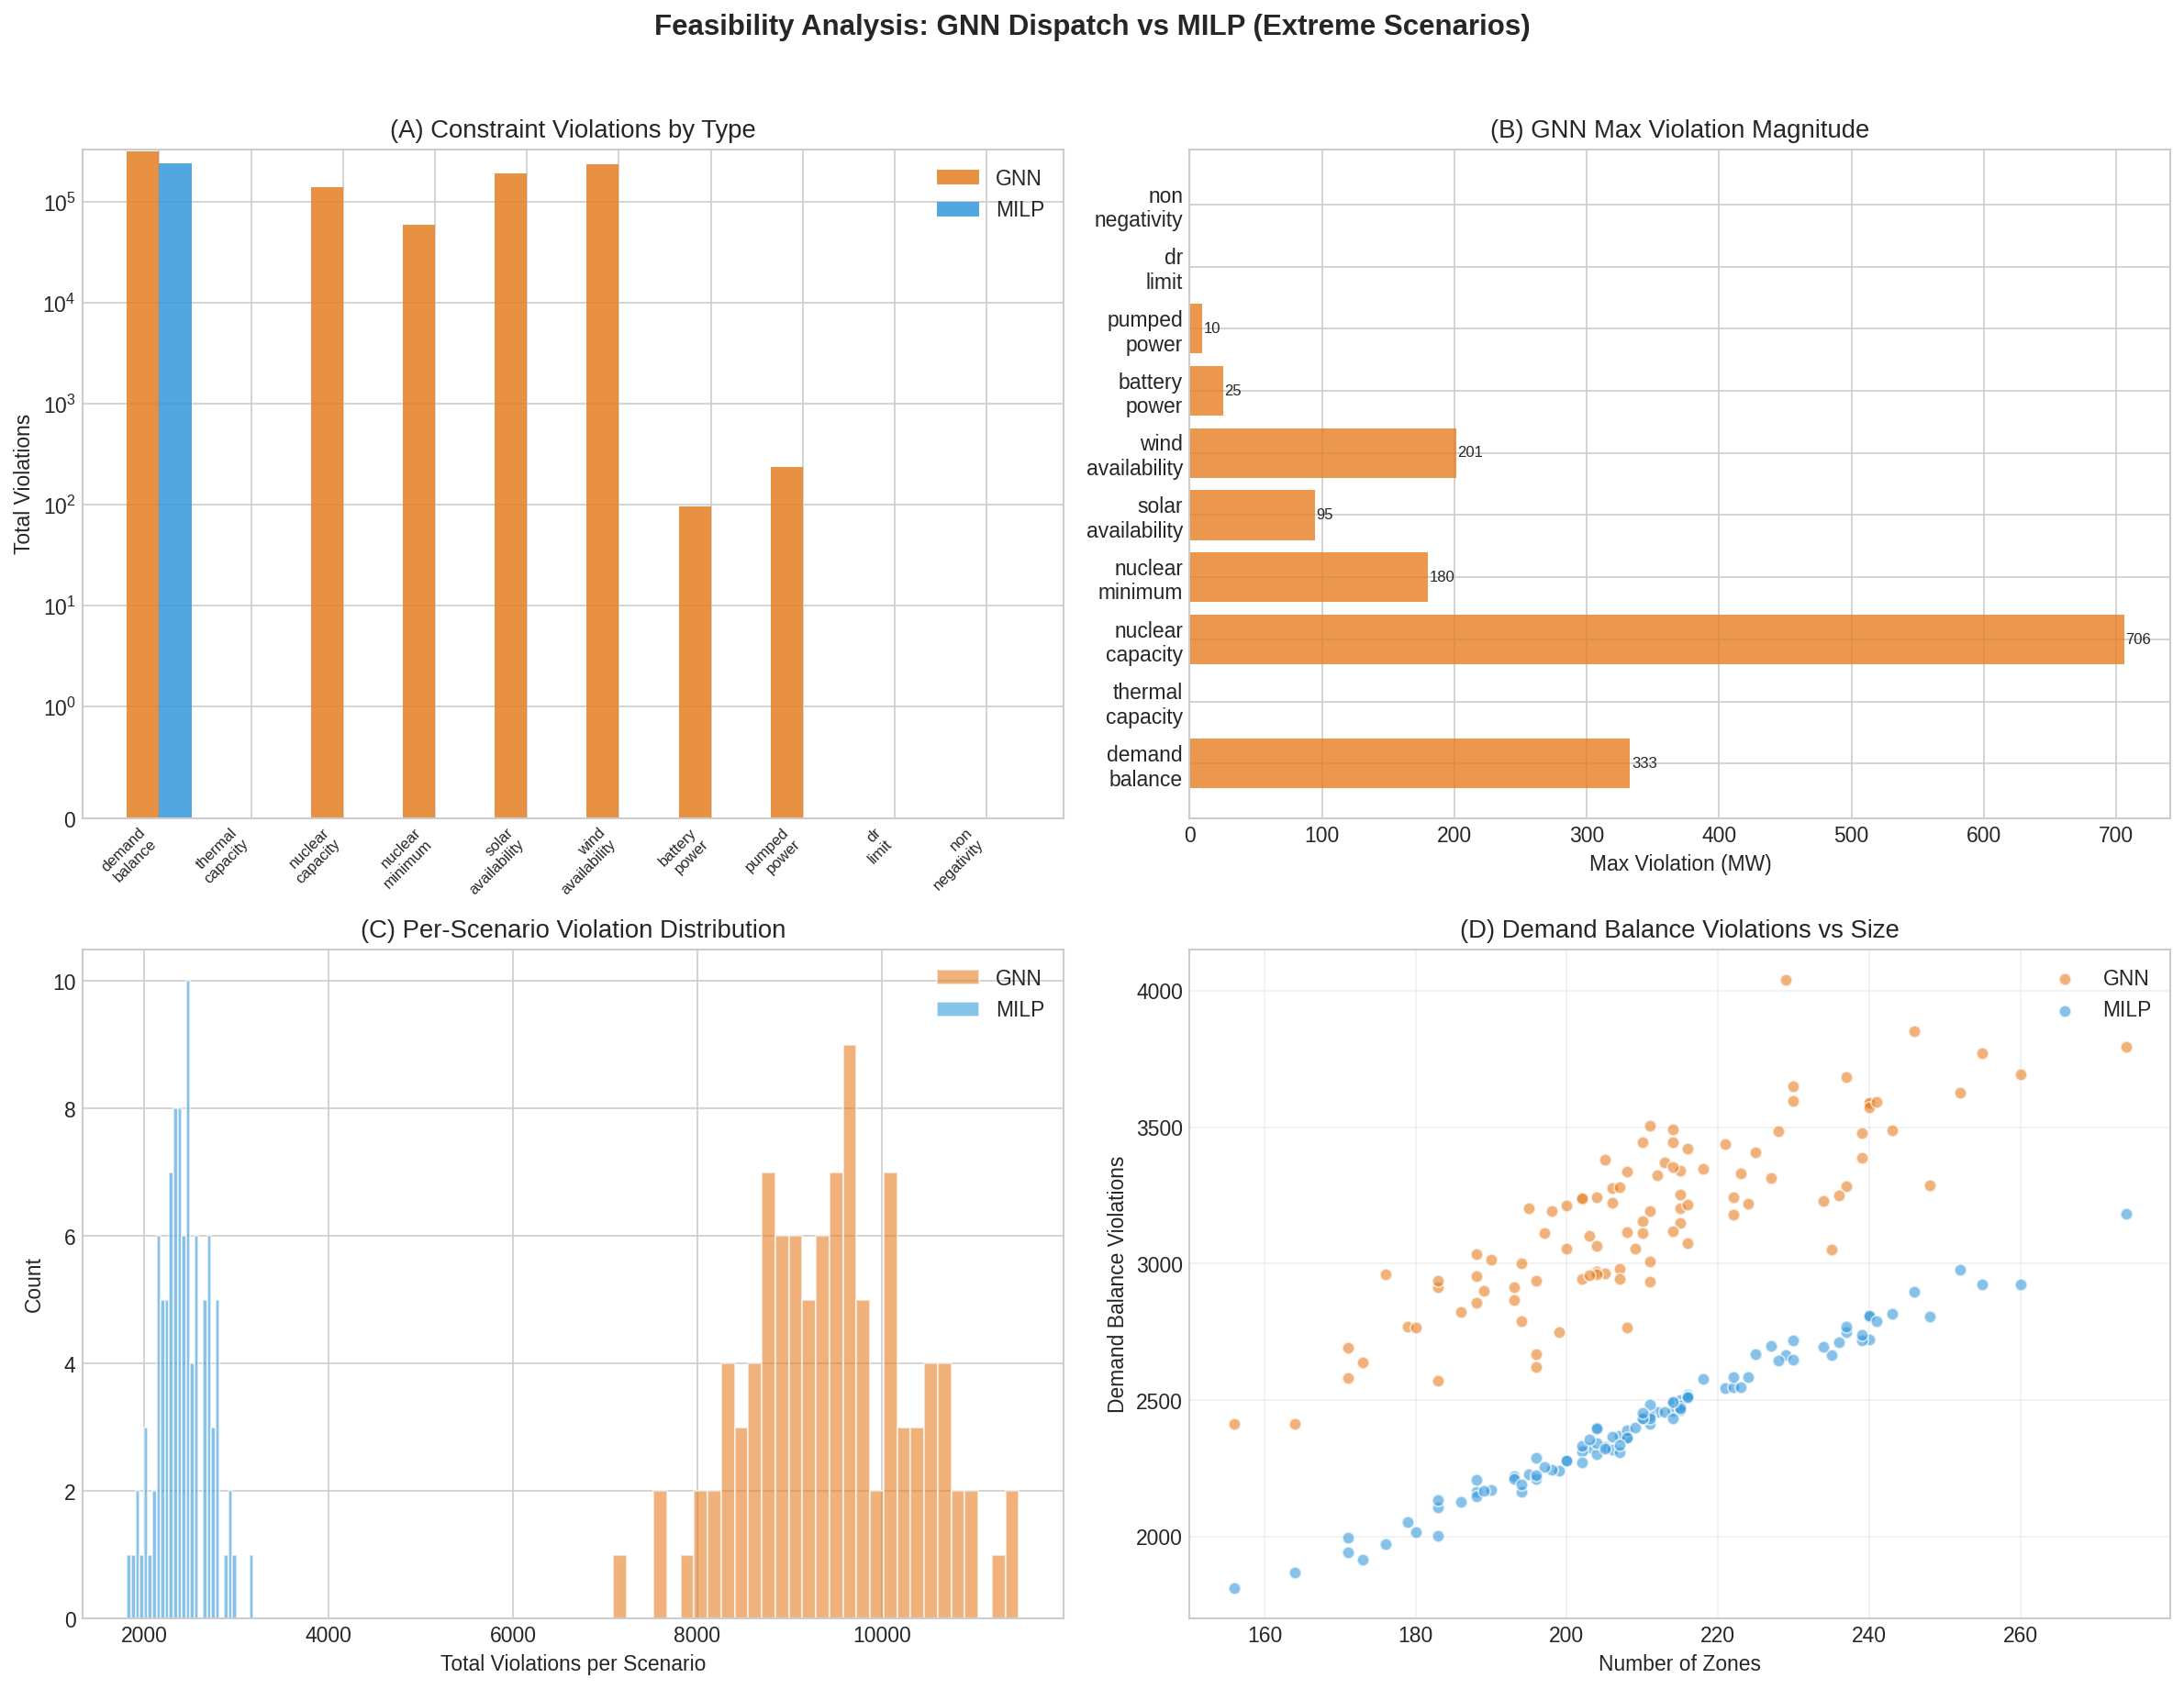

In [16]:
# ── Feasibility Visualisation ──

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Panel A: Violation counts per constraint type ──
ax = axes[0, 0]
gnn_counts = [df_feas[f'gnn_{ct}_count'].sum() for ct in constraint_types]
milp_counts = [df_feas[f'milp_{ct}_count'].sum() for ct in constraint_types]
ct_labels = [ct.replace('_', '\n') for ct in constraint_types]
x = np.arange(len(constraint_types))
w = 0.35
ax.bar(x - w/2, gnn_counts, w, label='GNN', color='#e67e22', alpha=0.85)
ax.bar(x + w/2, milp_counts, w, label='MILP', color='#3498db', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ct_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Total Violations')
ax.set_title('(A) Constraint Violations by Type')
ax.legend()
ax.set_yscale('symlog', linthresh=1)

# ── Panel B: Max violation magnitude per constraint ──
ax = axes[0, 1]
gnn_maxes = [df_feas[f'gnn_{ct}_max_mw'].max() for ct in constraint_types]
ax.barh(ct_labels, gnn_maxes, color='#e67e22', alpha=0.8)
ax.set_xlabel('Max Violation (MW)')
ax.set_title('(B) GNN Max Violation Magnitude')
ax.axvline(x=0, color='black', lw=0.5)
for i, v in enumerate(gnn_maxes):
    if v > 0:
        ax.text(v + 1, i, f'{v:.0f}', va='center', fontsize=8)

# ── Panel C: Per-scenario violation count distribution ──
ax = axes[1, 0]
per_scenario_gnn = sum(df_feas[f'gnn_{ct}_count'] for ct in constraint_types)
per_scenario_milp = sum(df_feas[f'milp_{ct}_count'] for ct in constraint_types)
ax.hist(per_scenario_gnn, bins=30, color='#e67e22', alpha=0.6, label='GNN', edgecolor='white')
ax.hist(per_scenario_milp, bins=30, color='#3498db', alpha=0.6, label='MILP', edgecolor='white')
ax.set_xlabel('Total Violations per Scenario')
ax.set_ylabel('Count')
ax.set_title('(C) Per-Scenario Violation Distribution')
ax.legend()

# ── Panel D: Demand balance violation vs n_zones ──
ax = axes[1, 1]
ax.scatter(df_feas['n_zones'], df_feas['gnn_demand_balance_count'],
           c='#e67e22', s=40, alpha=0.6, edgecolors='white', label='GNN')
ax.scatter(df_feas['n_zones'], df_feas['milp_demand_balance_count'],
           c='#3498db', s=40, alpha=0.6, edgecolors='white', label='MILP')
ax.set_xlabel('Number of Zones')
ax.set_ylabel('Demand Balance Violations')
ax.set_title('(D) Demand Balance Violations vs Size')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Feasibility Analysis: GNN Dispatch vs MILP (Extreme Scenarios)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_feasibility.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Final Summary

In [17]:
print('=' * 80)
print('GNN DISPATCH - FULL EVALUATION SUMMARY (EXTREME SCENARIOS)')
print('=' * 80)

print(f'\nScenarios evaluated: {len(df_cost)}')

# ── Cost objective ──
print(f'\n--- Cost Objective ---')
print(f'  MILP objective (mean):      {df_cost["milp_objective"].mean():>14,.0f} EUR')
print(f'  GNN objective (mean):       {df_cost["gnn_objective"].mean():>14,.0f} EUR')
print(f'  Cost gap (median):          {df_cost["cost_gap_pct"].median():>+14.1f} %')
print(f'  Cost gap (mean):            {df_cost["cost_gap_pct"].mean():>+14.1f} %')
print(f'  Cost gap (P10/P90):         {df_cost["cost_gap_pct"].quantile(0.1):>+.1f}% / '
      f'{df_cost["cost_gap_pct"].quantile(0.9):>+.1f}%')

# ── Dispatch accuracy ──
print(f'\n--- Dispatch Accuracy (MAE vs MILP) ---')
print(f'  Overall MAE:  {df_dispatch["mae_overall"].mean():.1f} +/- {df_dispatch["mae_overall"].std():.1f} MW')
for ch in DISPATCH_CHANNELS:
    col = f'mae_{ch}'
    if col in df_dispatch.columns:
        print(f'  {ch:>20s}: {df_dispatch[col].mean():.1f} MW')

# ── Feasibility ──
print(f'\n--- Feasibility ---')
total_gnn_v = sum(df_feas[f'gnn_{ct}_count'].sum() for ct in constraint_types)
total_checks_all = df_feas['total_checks'].sum() * len(constraint_types)
print(f'  Total GNN violations:   {total_gnn_v:,} / {total_checks_all:,} checks')
print(f'  Feasibility rate:       {100*(1 - total_gnn_v / max(total_checks_all, 1)):.2f}%')
print(f'  Worst constraints:')
for ct in constraint_types:
    v = df_feas[f'gnn_{ct}_count'].sum()
    if v > 0:
        m = df_feas[f'gnn_{ct}_max_mw'].max()
        print(f'    {ct:<22s}: {v:>6d} violations, max {m:.0f} MW')

# ── Speed ──
print(f'\n--- Speed ---')
gnn_total = df_gnn['time_total'].mean()
gnn_dispatch_only = df_gnn['time_decoder'].mean() + df_gnn['time_lp_solve'].mean()
print(f'  GNN pipeline total:     {gnn_total:.2f} s/scenario')
print(f'  GNN dispatch only:      {gnn_dispatch_only*1000:.1f} ms/scenario')
if HAS_BASELINE:
    bl_total = df_bl['pipeline_solve_time'].mean()
    bl_dec_lp = df_bl['time_decoder'].mean() + df_bl['time_lp_solve'].mean()
    print(f'  Baseline (dec+LP):      {bl_total:.2f} s/scenario')
    print(f'  Speedup (total):        {bl_total/gnn_total:.1f}x')
    print(f'  Speedup (dec+LP->GNN):  {bl_dec_lp/max(gnn_dispatch_only, 1e-6):.0f}x')

# ── Save all results ──
print(f'\n--- Output Files ---')
df_cost.to_json(OUTPUT_DIR / 'cost_objective_extreme.json', orient='records', indent=2)
df_feas.to_json(OUTPUT_DIR / 'feasibility_extreme.json', orient='records', indent=2)
print(f'  Cost data:        {OUTPUT_DIR / "cost_objective_extreme.json"}')
print(f'  Feasibility data: {OUTPUT_DIR / "feasibility_extreme.json"}')
print(f'  Fig 3 (cost):     {OUTPUT_DIR / "fig3_cost_objective.png"}')
print(f'  Fig 4 (feas):     {OUTPUT_DIR / "fig4_feasibility.png"}')
print('=' * 80)

GNN DISPATCH - FULL EVALUATION SUMMARY (EXTREME SCENARIOS)

Scenarios evaluated: 100

--- Cost Objective ---
  MILP objective (mean):         -25,092,083 EUR
  GNN objective (mean):           33,241,751 EUR
  Cost gap (median):                  +183.8 %
  Cost gap (mean):                    +522.7 %
  Cost gap (P10/P90):         +109.9% / +788.4%

--- Dispatch Accuracy (MAE vs MILP) ---
  Overall MAE:  12.0 +/- 0.4 MW
               thermal: 8.5 MW
               nuclear: 30.7 MW
                 solar: 22.6 MW
                  wind: 47.6 MW
        battery_charge: 0.8 MW
     battery_discharge: 1.3 MW
         pumped_charge: 0.1 MW
      pumped_discharge: 0.1 MW
       demand_response: 0.1 MW
              unserved: 0.1 MW
         hydro_release: 20.2 MW

--- Feasibility ---
  Total GNN violations:   944,695 / 5,054,640 checks
  Feasibility rate:       81.31%
  Worst constraints:
    demand_balance        : 317227 violations, max 333 MW
    nuclear_capacity      : 139161 violations, 